# CNN Architecture (Malaria Detection)
**Today's Plan**:
- Load the Malaria Cell images from folders with os
- **The Building Block**: Pooling, Stride, Padding, Explained.
- **The full CNN blueprint**: Tracking the data shape through it.
- Train a proper CNN to ~95% and evalute it
- Overfitting & how to fight it: Dropout and data augmentation

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plot
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Pick the GPU if one is available

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version: ", torch.__version__)
print("Using Device: ", device)

if device.type == "cuda":
    print("GPU Name", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -- on kaggle, anable it via Setting > Accelerator > GPU.")

Torch version:  2.10.0+cu128
Using Device:  cuda
GPU Name Tesla T4


----

## 1. Load the Malaria Cell Images with a custom `Dataset`

In [3]:
DATA_DIR = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

VALID_EXT = (".png", ".jpg", ".jpeg")

class_names = os.listdir(DATA_DIR)

print("Class Names : ", class_names)

Class Names :  ['Uninfected', 'Parasitized']


In [4]:
all_paths = []
all_labels = []

for idx, class_name in enumerate(class_names):
    class_folder = os.path.join(DATA_DIR, class_name)
    for file_name in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file_name)

        if file_name.lower().endswith(VALID_EXT):
            all_paths.append(file_path)
            all_labels.append(idx)


print(f"Total paths Found: {len(all_paths)}")
print(f"Number of Classes: {len(class_names)}")
print()

# images per class
print(f"class : {class_names[0]:14s} Total Paths: {all_labels.count(0)}")
print(f"class : {class_names[1]:14s} Total Paths: {all_labels.count(1)}")

Total paths Found: 27558
Number of Classes: 2

class : Uninfected     Total Paths: 13779
class : Parasitized    Total Paths: 13779


In [5]:
class MalariaDataset(Dataset):
    """Stores only file paths; loads each image lazily in __getitem__"""
    def __init__(self, paths, labels, img_size=64):
        self.paths = paths
        self.labels = labels
        self.img_size = img_size

    def __getitem__(self, idx):
        # 1. Open one image from disk
        # 2. Resize to img_size
        # 3. Convert to numpy array and Scale to 0-1  (img/255.0)
        # 4. Reshape to (Channels, H, W)
        
        img = Image.open(self.paths[idx]).convert("RGB")
        img = img.resize((self.img_size, self.img_size))
        arr = np.asarray(img, dtype="float32") / 255.0            # (H, W, 3)
        tensor = torch.from_numpy(arr).permute(2, 0, 1)              # -> (3, H, W)

        # Return image and corresponding label
        return tensor, self.labels[idx]

    def __len__(self):
        return len(self.paths)
            

### Splits the PATHS (not the images) into train/test and create dataset object

In [6]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)

train_ds = MalariaDataset(train_paths, train_labels, 64)
test_ds  = MalariaDataset(test_paths,  test_labels,  64)

print(f"Training Images : {len(train_ds)}")
print(f"Test Images : {len(test_ds)}")

Training Images : 22046
Test Images : 5512


### Wrap the Datasets in DataLoaders

In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

n_classes = len(class_names)
print("batches per epoch (train):", len(train_loader))
print("CNN input shape per batch: (batch, 3 channels, 64, 64)")

batches per epoch (train): 22046
CNN input shape per batch: (batch, 3 channels, 64, 64)


### A function that calculate accuracy for a dataloader

In [8]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(1)
        correct += (pred == yb).sum().item()
        total += len(yb)
    return correct / total

---

## 2. The full CNN blueprint

Almost every classic CNN follows one pattern:

> **[ Conv → ReLU → Pool ] × N  →  Flatten  →  Dense → output**

A stack of conv-pool blocks (the **feature extractor**), then a couple of dense layers (the **classifier**). Each block’s conv *keeps* the size (padding=1) and its pool *halves* it, so the picture gets smaller and deeper as it flows through.

Let’s track the shape through our network so the flatten size is no mystery:

| Stage | Shape (channels × H × W) |
|---|---|
| input | 3 × 64 × 64 |
| block 1: conv→pool | 16 × 32 × 32 |
| block 2: conv→pool | 32 × 16 × 16 |
| block 3: conv→pool | 64 × 8 × 8 |
| flatten | 64 × 8 × 8 = **4096** |

That **4096** is what the first dense layer must expect. Get the shape-tracking right and the network just works.

In [9]:
class MalariaCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 3 -> 16 channels, then halve 64 -> 32
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # block 2: 16 -> 32, halve 32 -> 16
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # block 3: 32 -> 64, halve 16 -> 8
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # 64 * 8 * 8 = 4096
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(42)
model = MalariaCNN(n_classes)
model = model.to(device)         # move model to GPU
print(model)

MalariaCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


---
## 3. Train the CNN

Same four-move training loop you’ve used all week — forward → loss → backward → update. We track **both train and test accuracy** each epoch so we can watch for overfitting

In [10]:
lr = 0.001

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [11]:
epochs = 12

train_accs = []
test_accs = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)      # move batch to GPU
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    tr = accuracy(model, train_loader)
    te = accuracy(model, test_loader)
    train_accs.append(tr)
    test_accs.append(te)
    
    print(f"epoch {epoch+1:2d}  train acc {tr:.2%}   test acc {te:.2%}")

epoch  1  train acc 95.66%   test acc 95.75%
epoch  2  train acc 95.72%   test acc 95.43%
epoch  3  train acc 94.91%   test acc 94.94%
epoch  4  train acc 95.96%   test acc 95.75%
epoch  5  train acc 91.59%   test acc 91.55%
epoch  6  train acc 96.12%   test acc 95.63%
epoch  7  train acc 96.08%   test acc 95.68%
epoch  8  train acc 96.12%   test acc 95.46%
epoch  9  train acc 96.09%   test acc 95.34%
epoch 10  train acc 95.95%   test acc 95.25%
epoch 11  train acc 95.47%   test acc 94.59%
epoch 12  train acc 96.27%   test acc 95.79%


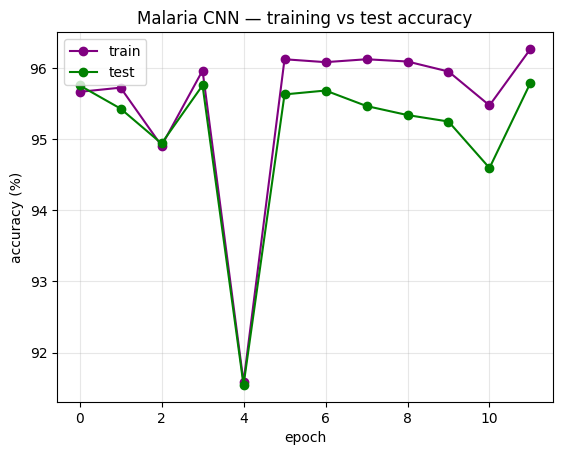

final test accuracy: 95.79%


In [14]:
plt.plot([a*100 for a in train_accs], marker="o", label="train", color="purple")
plt.plot([a*100 for a in test_accs], marker="o", label="test", color="green")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Malaria CNN — training vs test accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"final test accuracy: {test_accs[-1]:.2%}")

## 4. Evaluate the Detector

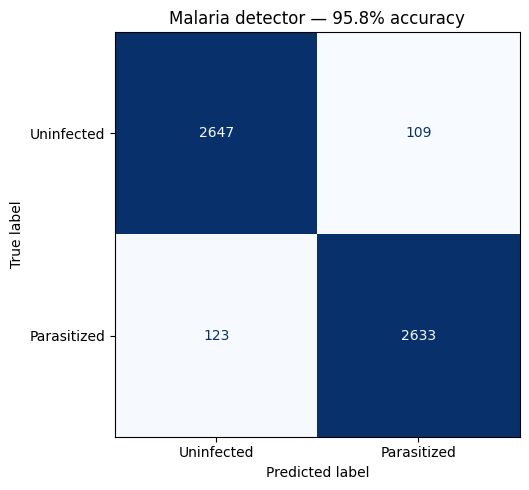

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# collect predictions + truths by streaming the test loader
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_pred.extend(model(xb).argmax(1).cpu().tolist())
        all_true.extend(yb.tolist())
test_acc = np.mean(np.array(all_pred) == np.array(all_true))

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Malaria detector — {test_acc:.1%} accuracy")
plt.tight_layout()
plt.show()

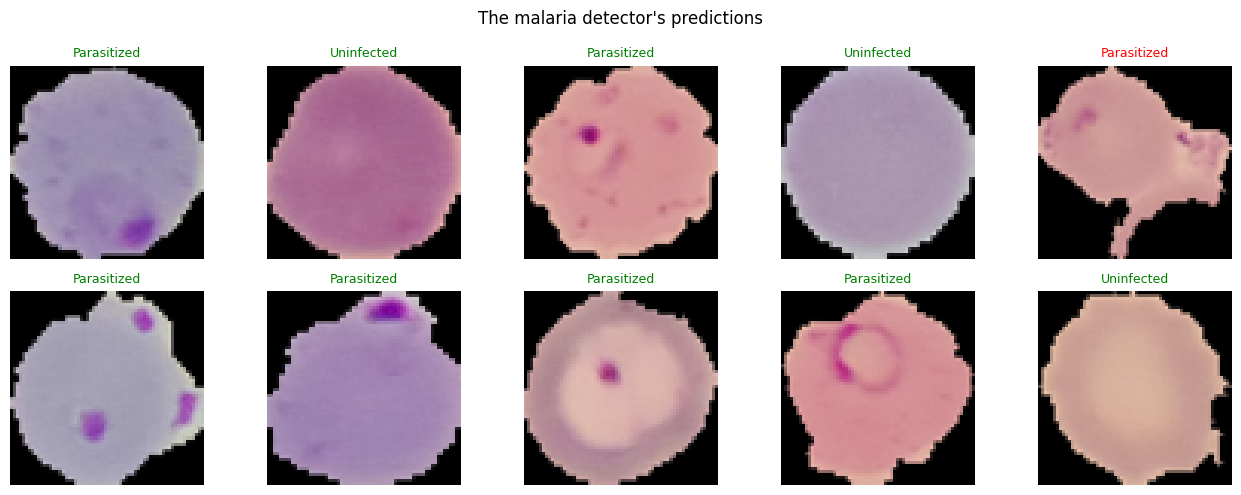

In [16]:
# see the detector at work — green = correct, red = wrong
model.eval()
plt.figure(figsize=(13, 5))
with torch.no_grad():
    for i in range(10):
        img_t, true_lab = test_ds[i]                       # loads one image (on CPU)
        pred = model(img_t.unsqueeze(0).to(device)).argmax(1).item()
        plt.subplot(2, 5, i+1)
        plt.imshow(img_t.permute(1, 2, 0).numpy())         # plot from the CPU tensor
        plt.title(class_names[pred], color="green" if pred == true_lab else "red", fontsize=9)
        plt.axis("off")
plt.suptitle("The malaria detector's predictions")
plt.tight_layout()
plt.show()